# Этап 1 (вертикальный срез) — выгрузка данных ERA5 через Open-Meteo

Этот ноутбук выполняет первую часть «вертикального среза» проекта
(см. `PROJECT_BRIEF.md`, раздел 5):

1. скачивает почасовые данные реанализа **ERA5** через **Open-Meteo Historical
   Weather API** (`/v1/archive`) для станции Кандалакша (ВМО 22217) за контрольный
   период из `config.yaml`;
2. сохраняет сырой ответ (JSON) в `data/raw/` — это кэш: повторный запуск без
   удаления файла НЕ перевыгружает данные заново (воспроизводимость, раздел 3.1
   брифа);
3. приводит данные к таблице pandas, проверяет покрытие периода и пропуски;
4. помечает источник записей (`source = "era5"`) и сохраняет таблицу в
   `data/clean/`;
5. фиксирует дату фактической выгрузки в `config.yaml` (`period.download_date`).

**О самом источнике.** ERA5 — это реанализ ECMWF/Copernicus: модель атмосферы,
"подогнанная" под реальные наблюдения по всему миру, даёт непрерывную (без
пропусков) почасовую сетку данных с разрешением ~25 км. Open-Meteo предоставляет
к нему бесплатный доступ без авторизации (лицензия CC BY 4.0). Важно: это
**модельная оценка** для ближайшего узла сетки, а не прямой замер на станции, и
в ней нет кодов наблюдённых явлений (гололёд, мокрый снег и т.п.) — только
числовые метеовеличины.


In [1]:
# Стандартные и сторонние библиотеки.
# requests  - HTTP-запросы к Open-Meteo API
# pandas    - таблицы данных
# yaml      - чтение config.yaml
# json      - сохранение/чтение сырого ответа API
# pathlib   - кроссплатформенная работа с путями
# datetime  - метка даты фактической выгрузки
import json
from datetime import date
from pathlib import Path

import pandas as pd
import requests
import yaml

%matplotlib inline


def find_project_root(start: Path) -> Path:
    """Находит корень проекта — каталог, где лежит config.yaml.

    Нужно потому, что рабочий каталог Jupyter зависит от того, как запущен
    ноутбук (из корня проекта или из ingest/), а config.yaml должен находиться
    однозначно вне зависимости от этого.
    """
    for parent in [start, *start.parents]:
        if (parent / "config.yaml").exists():
            return parent
    raise FileNotFoundError("Не найден config.yaml — проверьте, откуда запущен ноутбук")


PROJECT_ROOT = find_project_root(Path.cwd())
CONFIG_PATH = PROJECT_ROOT / "config.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

station = config["station"]
period = config["period"]
era5_cfg = config["sources"]["era5"]

print(f"Корень проекта: {PROJECT_ROOT}")
print(f"Станция: {station['name']} (ВМО {station['wmo_id']})")
print(f"Координаты: {station['latitude']}, {station['longitude']}")
print(f"Период выгрузки: {period['start_date']} — {period['end_date']}")


Корень проекта: /Users/golochalov/IdeaProjects/Climate analysis
Станция: Кандалакша (ВМО 22217)
Координаты: 67.15123, 32.41284
Период выгрузки: 2024-01-01 — 2024-12-31


## Формирование запроса к Open-Meteo Archive API

Документация: https://open-meteo.com/en/docs/historical-weather-api

Список почасовых переменных (`hourly_variables`) и часовой пояс берутся из
`config.yaml` (раздел `sources.era5`), чтобы при необходимости расширить набор
переменных не пришлось трогать код ноутбука.


In [2]:
# Параметры запроса:
# - latitude/longitude   - координаты станции Кандалакша из config.yaml
# - start_date/end_date  - контрольный период (YYYY-MM-DD)
# - hourly                - список почасовых переменных через запятую
# - timezone              - часовой пояс меток времени в ответе API
params = {
    "latitude": station["latitude"],
    "longitude": station["longitude"],
    "start_date": period["start_date"],
    "end_date": period["end_date"],
    "hourly": ",".join(era5_cfg["hourly_variables"]),
    "timezone": era5_cfg["timezone"],
}
params


{'latitude': 67.15123,
 'longitude': 32.41284,
 'start_date': '2024-01-01',
 'end_date': '2024-12-31',
 'hourly': 'temperature_2m,relative_humidity_2m,precipitation,snowfall,pressure_msl,wind_speed_10m,wind_gusts_10m',
 'timezone': 'Europe/Moscow'}

## Загрузка с кэшированием

Сырой ответ API сохраняется в `data/raw/` под именем, включающим станцию,
период и идентификатор источника. Если файл уже существует — запрос к API не
повторяется (см. раздел 6 брифа: "Сырые выгрузки кэшировать на диск; не
перевыгружать без необходимости").


In [3]:
RAW_DIR = PROJECT_ROOT / config["paths"]["raw_dir"]
RAW_DIR.mkdir(parents=True, exist_ok=True)

raw_filename = (
    f"era5_kandalaksha_{station['wmo_id']}_"
    f"{period['start_date']}_{period['end_date']}.json"
)
raw_path = RAW_DIR / raw_filename

if raw_path.exists():
    # Файл уже скачан ранее - читаем из кэша, не дёргаем API повторно
    print(f"Используем кэш: {raw_path.relative_to(PROJECT_ROOT)}")
    with open(raw_path, "r", encoding="utf-8") as f:
        era5_raw = json.load(f)
else:
    print("Кэш не найден, выполняем запрос к Open-Meteo...")
    response = requests.get(era5_cfg["base_url"], params=params, timeout=60)
    response.raise_for_status()
    era5_raw = response.json()
    with open(raw_path, "w", encoding="utf-8") as f:
        json.dump(era5_raw, f, ensure_ascii=False, indent=2)
    print(f"Сохранено: {raw_path.relative_to(PROJECT_ROOT)}")

print(f"Часовой пояс ответа: {era5_raw.get('timezone')}")
print(f"Высота узла модельной сетки: {era5_raw.get('elevation')} м "
      f"(в config.yaml высота станции: {station['elevation_m']} м)")


Кэш не найден, выполняем запрос к Open-Meteo...


Сохранено: data/raw/era5_kandalaksha_22217_2024-01-01_2024-12-31.json
Часовой пояс ответа: Europe/Moscow
Высота узла модельной сетки: 33.0 м (в config.yaml высота станции: 29 м)


## Преобразование в таблицу pandas

Поле `hourly` в ответе API — словарь списков одинаковой длины (`time`,
`temperature_2m`, `relative_humidity_2m`, ...). Превращаем его в DataFrame и
парсим временную метку.


In [4]:
hourly = era5_raw["hourly"]
df_era5 = pd.DataFrame(hourly)
df_era5["time"] = pd.to_datetime(df_era5["time"])
df_era5 = df_era5.rename(columns={"time": "datetime"})

print(f"Строк: {len(df_era5)}")
print(f"Колонки: {list(df_era5.columns)}")
df_era5.head()


Строк: 8784
Колонки: ['datetime', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'snowfall', 'pressure_msl', 'wind_speed_10m', 'wind_gusts_10m']


,datetime,temperature_2m,relative_humidity_2m,precipitation,snowfall,pressure_msl,wind_speed_10m,wind_gusts_10m
0,2024-01-01 00:00:00,-19.5,87,0.0,0.0,1027.1,5.0,12.2
1,2024-01-01 01:00:00,-18.2,85,0.0,0.0,1027.2,6.4,11.5
2,2024-01-01 02:00:00,-18.0,84,0.0,0.0,1027.5,8.8,15.1
3,2024-01-01 03:00:00,-17.4,83,0.0,0.0,1027.7,9.8,17.3
4,2024-01-01 04:00:00,-17.6,81,0.0,0.0,1028.2,9.0,17.3


## Проверка покрытия периода и пропусков

ERA5 — модельный продукт без пропусков по построению, но проверяем явно: для
отчёта (раздел 6 брифа требует "журнал обработки пропусков") и на случай сбоя
самого API.


In [5]:
# Ожидаемое число часов за период (включительно)
expected_hours = pd.date_range(
    start=period["start_date"],
    end=pd.Timestamp(period["end_date"]) + pd.Timedelta(days=1) - pd.Timedelta(hours=1),
    freq="h",
)
missing_hours = expected_hours.difference(df_era5["datetime"])

print(f"Ожидается часов за период: {len(expected_hours)}")
print(f"Получено строк от API:     {len(df_era5)}")
print(f"Пропущено меток времени:    {len(missing_hours)}")

# Пропуски (NaN) внутри полученных данных по каждой переменной
print("\nПропуски (NaN) по колонкам:")
df_era5.isna().sum()


Ожидается часов за период: 8784
Получено строк от API:     8784
Пропущено меток времени:    0

Пропуски (NaN) по колонкам:


datetime                0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
snowfall                0
pressure_msl            0
wind_speed_10m          0
wind_gusts_10m          0
dtype: int64

## Пометка источника и сохранение в `data/clean/`

Каждая запись в итоговой БД должна нести поле `source` (раздел 3.4 брифа).
Здесь — `"era5"`. Сохраняем промежуточный CSV; загрузка в SQLite по схеме
`weather_data` будет выполнена в отдельном ноутбуке (`db/`).


In [6]:
df_era5["source"] = "era5"

CLEAN_DIR = PROJECT_ROOT / config["paths"]["clean_dir"]
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

clean_path = CLEAN_DIR / f"era5_kandalaksha_{period['start_date']}_{period['end_date']}.csv"
df_era5.to_csv(clean_path, index=False)
print(f"Сохранено: {clean_path.relative_to(PROJECT_ROOT)} ({len(df_era5)} строк)")
df_era5.head()


Сохранено: data/clean/era5_kandalaksha_2024-01-01_2024-12-31.csv (8784 строк)


,datetime,temperature_2m,relative_humidity_2m,precipitation,snowfall,pressure_msl,wind_speed_10m,wind_gusts_10m,source
0,2024-01-01 00:00:00,-19.5,87,0.0,0.0,1027.1,5.0,12.2,era5
1,2024-01-01 01:00:00,-18.2,85,0.0,0.0,1027.2,6.4,11.5,era5
2,2024-01-01 02:00:00,-18.0,84,0.0,0.0,1027.5,8.8,15.1,era5
3,2024-01-01 03:00:00,-17.4,83,0.0,0.0,1027.7,9.8,17.3,era5
4,2024-01-01 04:00:00,-17.6,81,0.0,0.0,1028.2,9.0,17.3,era5



Колонка	Описание	Единица
datetime	Дата и время наблюдения	Europe/Moscow (из конфига)
temperature_2m	Температура воздуха на высоте 2 м	°C
relative_humidity_2m	Относительная влажность на высоте 2 м	%
precipitation	Сумма осадков за час	мм
snowfall	Сумма снегопада за час	см
pressure_msl	Атмосферное давление, приведённое к уровню моря	гПа
wind_speed_10m	Скорость ветра на высоте 10 м	км/ч
wind_gusts_10m	Скорость порывов ветра на высоте 10 м	км/ч
source	Источник записи (era5 = реанализ ERA5/Open-Meteo)	—
Единицы взяты из hourly_units сырого ответа API (data/raw/era5_kandalaksha_22217_2024-01-01_2024-12-31.json).

## Фиксация даты выгрузки в `config.yaml`

Раздел 3.1 брифа: "повторная выгрузка в середине проекта ломает
воспроизводимость" — поэтому дата первой реальной выгрузки фиксируется
автоматически и больше не меняется.

Делаем точечную замену строки `download_date: null` в тексте файла (а не
`yaml.safe_dump` всей структуры), чтобы не потерять комментарии и форматирование
`config.yaml`.


In [7]:
if config["period"]["download_date"] is None:
    today = date.today().isoformat()
    config_text = CONFIG_PATH.read_text(encoding="utf-8")
    config_text = config_text.replace(
        "download_date: null",
        f'download_date: "{today}"  # зафиксировано автоматически при первой выгрузке ERA5',
    )
    CONFIG_PATH.write_text(config_text, encoding="utf-8")
    print(f"download_date зафиксирован: {today}")
else:
    print(f"download_date уже зафиксирован ранее: {config['period']['download_date']}")


download_date зафиксирован: 2026-06-10


## Контрольный график

Быстрая визуальная проверка: ход температуры воздуха за весь контрольный
период. Это тот же график, который на следующем шаге дополнится данными
станции (rp5/meteo.ru) на тех же осях для сравнения источников.


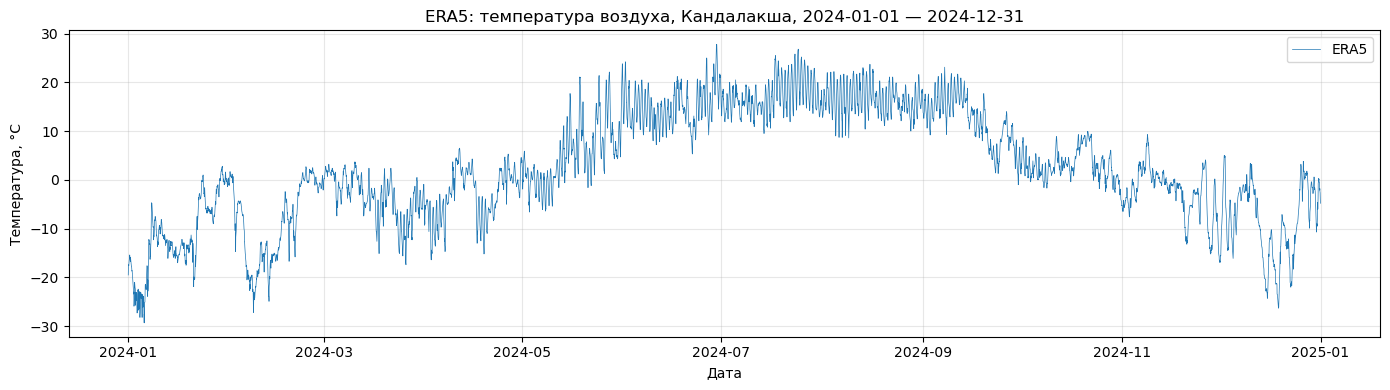

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_era5["datetime"], df_era5["temperature_2m"], linewidth=0.5, color="tab:blue", label="ERA5")
ax.set_title(f"ERA5: температура воздуха, {station['name']}, {period['start_date']} — {period['end_date']}")
ax.set_xlabel("Дата")
ax.set_ylabel("Температура, °C")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Итог

- Данные ERA5 за контрольный период выгружены и закэшированы в `data/raw/`.
- Таблица с пометкой `source = "era5"` сохранена в `data/clean/`.
- Дата выгрузки зафиксирована в `config.yaml`.

**Следующий шаг:** выгрузка данных станции Кандалакша (rp5.ru / meteo.ru) за
тот же период — ноутбук `ingest/02_station_ingest.ipynb`.
